# 🎮 Steam Nexus: Data Engineering Pipeline (Reviews)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

PATH_REVIEWS = "../data/raw/steam_reviews_raw.csv"

df_reviews = pd.read_csv(PATH_REVIEWS, low_memory=False)
print("✅ Reviews dataset loaded for analysis.")

✅ Reviews dataset loaded for analysis.


## 🔍 1. Structural Recognition
Identifying the dataset magnitude and the initial state of data types.

In [13]:
print(f"📏 Dimensions: {df_reviews.shape[0]} rows x {df_reviews.shape[1]} columns")
print(f"\n📋 Column Names:\n{df_reviews.columns.tolist()}")
display(df_reviews.head(3))

📏 Dimensions: 6417106 rows x 5 columns

📋 Column Names:
['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']


,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,This will be more of a ''my experience with th...,1,1
2,10,Counter-Strike,This game saved my virginity.,1,0


In [14]:
print("\n--- Initial Data Types ---")
df_reviews.info()


--- Initial Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 6417106 entries, 0 to 6417105
Data columns (total 5 columns):
 #   Column        Dtype
---  ------        -----
 0   app_id        int64
 1   app_name      str  
 2   review_text   str  
 3   review_score  int64
 4   review_votes  int64
dtypes: int64(3), str(2)
memory usage: 244.8 MB


In [15]:
print("\n--- Missing Values ---")
missing_data = df_reviews.isnull().sum()
missing_percentage = (missing_data / len(df_reviews)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))


--- Missing Values ---
             Missing Count  Percentage
app_name            183234    2.855399
review_text           7305    0.113836


In [16]:
print("\n--- Memory Estimation ---")
mem_usage = df_reviews.memory_usage(deep=True).sum() / (1024**2)
print(f"Total memory used by DataFrame: {mem_usage:.2f} MB")


--- Memory Estimation ---
Total memory used by DataFrame: 3030.99 MB


### 1.2 Scale and Composition Analysis
Extending our structural recognition to understand the granularity and dispersion of our data through unique counts and descriptive statistics.

In [17]:
print("\n--- Unique Values Count (Selected Columns) ---")
unique_counts = {}
for col in df_reviews.columns:
    unique_counts[col] = df_reviews[col].nunique()

for col, count in sorted(unique_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"'{col}': {count} unique values")


--- Unique Values Count (Selected Columns) ---
'review_text': 4473473 unique values
'app_id': 9972 unique values
'app_name': 9363 unique values
'review_score': 2 unique values
'review_votes': 2 unique values


In [18]:
print("\n--- Descriptive Statistics (Numerical Columns) ---")
numeric_cols = df_reviews.select_dtypes(include=[np.number]).columns
display(df_reviews[numeric_cols].describe().transpose())


--- Descriptive Statistics (Numerical Columns) ---


,count,mean,std,min,25%,50%,75%,max
app_id,6417106.0,227469.499959,126045.065780,10.0,201810.0,239160.0,305620.0,565340.0
review_score,6417106.0,0.639499,0.768792,-1.0,1.0,1.0,1.0,1.0
review_votes,6417106.0,0.147245,0.354350,0.0,0.0,0.0,0.0,1.0


## 🎯 Step 2: Hypothesis and Visualization Based Justification

In this section, we visually demonstrate why we selected each critical variable for our data product.

### 2.1 `review_score` Justification (Review Rating)
**Hypothesis:** The review score is a numerical indicator of user satisfaction with a game, ranging across multiple levels. This distribution is crucial for understanding user sentiment and building satisfaction-based recommendation models.

**Visual Evidence:**

📊 Using column: 'review_score'


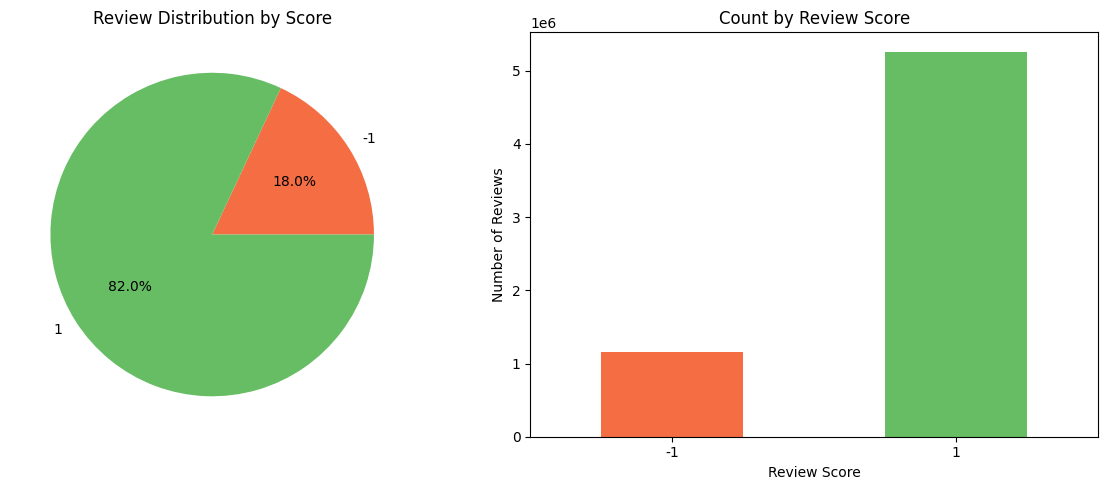

Conclusion: Review score distribution shows varied user satisfaction levels.


In [24]:
# Use review_score for sentiment analysis
if 'review_score' in df_reviews.columns:
    print(f"📊 Using column: 'review_score'")
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Pie chart
    sentiment_counts = df_reviews['review_score'].value_counts().sort_index()
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sentiment_counts)))
    ax[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors)
    ax[0].set_title("Review Distribution by Score")
    
    # Bar chart
    sentiment_counts.plot(kind='bar', ax=ax[1], color=colors)
    ax[1].set_title("Count by Review Score")
    ax[1].set_ylabel("Number of Reviews")
    ax[1].set_xlabel("Review Score")
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()
    print("Conclusion: Review score distribution shows varied user satisfaction levels.")
else:
    print("⚠️ No review_score column found. Available columns:")
    print(df_reviews.columns.tolist())

### 2.2 `review_votes` Justification (Review Helpfulness)
**Hypothesis:** The number of votes a review receives indicates its usefulness and relevance to the community. This metric is essential for identifying high-quality reviews and ranking them for better visibility.

**Visual Evidence:**

📊 Using column: 'review_votes'


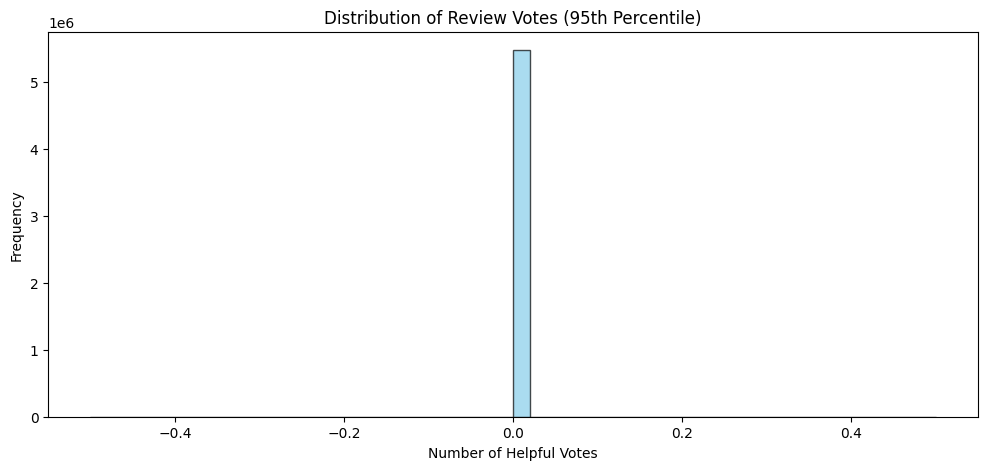

Mean review_votes: 0.15
Median review_votes: 0.00
Max review_votes: 1
Conclusion: Vote counts vary widely, making them valuable for quality assessment.


In [25]:
# Use review_votes for helpfulness analysis
if 'review_votes' in df_reviews.columns:
    print(f"📊 Using column: 'review_votes'")
    
    # Convert to numeric if needed
    votes_numeric = pd.to_numeric(df_reviews['review_votes'], errors='coerce').fillna(0)
    
    plt.figure(figsize=(12, 5))
    
    # Histogram with cap to avoid extreme outliers
    if votes_numeric.max() > 0:
        votes_capped = votes_numeric[votes_numeric < votes_numeric.quantile(0.95)]
        plt.hist(votes_capped, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        plt.title("Distribution of Review Votes (95th Percentile)")
        plt.xlabel("Number of Helpful Votes")
        plt.ylabel("Frequency")
        plt.show()
        
        print(f"Mean review_votes: {votes_numeric.mean():.2f}")
        print(f"Median review_votes: {votes_numeric.median():.2f}")
        print(f"Max review_votes: {votes_numeric.max():.0f}")
        print("Conclusion: Vote counts vary widely, making them valuable for quality assessment.")
    else:
        print(f"⚠️ Column 'review_votes' has no numeric values")
else:
    print("⚠️ No review_votes column found. Available columns:")
    print(df_reviews.columns.tolist())

### 2.3 `review_text` Justification (Content Analysis)
**Hypothesis:** Review text contains valuable sentiment, opinions, and reasoning for why users recommend or don't recommend games. This textual content is essential for natural language processing, topic modeling, and content-based recommendations.

**Visual Evidence:**

📊 Using column: 'review_text'


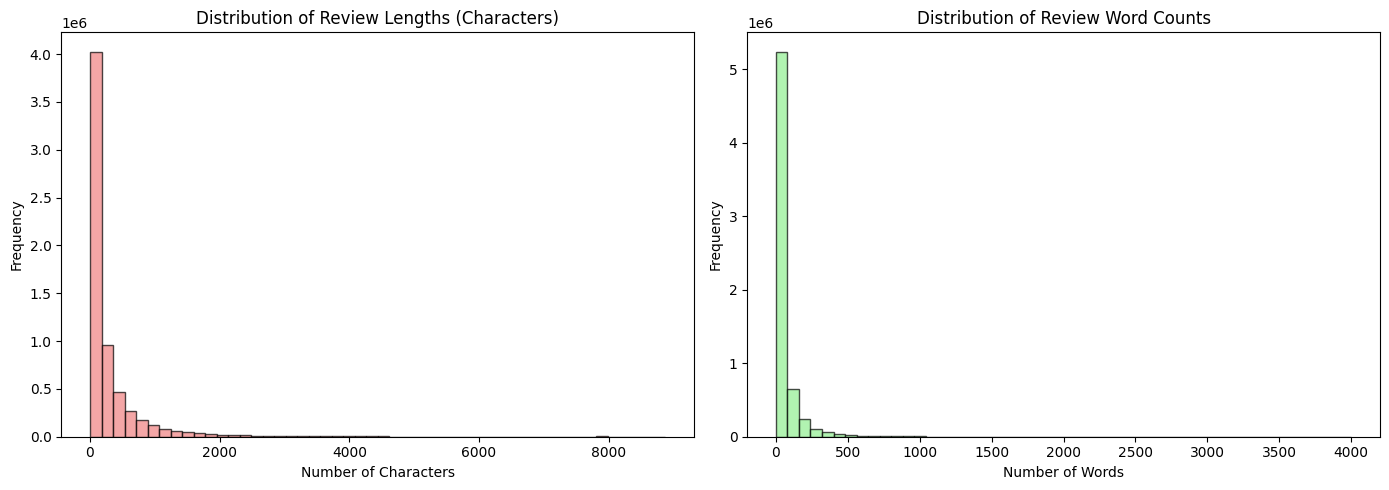

Average review length: 304 characters
Average word count: 55 words
Empty reviews: 7305
Conclusion: Text length variation justifies NLP preprocessing.


In [26]:
# Find text column
text_cols = [col for col in df_reviews.columns if any(x in col.lower() for x in ['review_text', 'text', 'comment', 'content'])]

if text_cols:
    text_col = text_cols[0]
    print(f"📊 Using column: '{text_col}'")
    
    # Calculate text lengths
    df_reviews['review_length'] = df_reviews[text_col].fillna('').str.len()
    df_reviews['review_word_count'] = df_reviews[text_col].fillna('').str.split().str.len()
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Character length distribution
    char_lengths = df_reviews[df_reviews['review_length'] > 0]['review_length']
    ax[0].hist(char_lengths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    ax[0].set_title("Distribution of Review Lengths (Characters)")
    ax[0].set_xlabel("Number of Characters")
    ax[0].set_ylabel("Frequency")
    
    # Word count distribution
    word_counts = df_reviews[df_reviews['review_word_count'] > 0]['review_word_count']
    ax[1].hist(word_counts, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    ax[1].set_title("Distribution of Review Word Counts")
    ax[1].set_xlabel("Number of Words")
    ax[1].set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Average review length: {char_lengths.mean():.0f} characters")
    print(f"Average word count: {word_counts.mean():.0f} words")
    print(f"Empty reviews: {(df_reviews['review_length'] == 0).sum()}")
    print("Conclusion: Text length variation justifies NLP preprocessing.")
else:
    print("⚠️ No text column found. Available columns:")
    print(df_reviews.columns.tolist())

## 🛠️ Step 3: Cleaning and Working Table Creation
After justifying the variables, we generate the final clean dataset.

In [28]:
# Select columns that are present in reviews dataset
available_cols = [col for col in df_reviews.columns if col in ['app_id', 'app_name', 'review_text', 'review_score', 'review_votes', 'user_id', 'language', 'playtime_forever', 'last_edited']]
if available_cols:
    df_review_work = df_reviews[available_cols].copy()
else:
    # If specific columns don't exist, use all columns
    df_review_work = df_reviews.copy()

print(f"Selected {df_review_work.shape[1]} columns for processing")
print(f"Columns: {list(df_review_work.columns)}")
display(df_review_work.head())

Selected 5 columns for processing
Columns: ['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']


,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,This will be more of a ''my experience with th...,1,1
2,10,Counter-Strike,This game saved my virginity.,1,0
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,1,0
4,10,Counter-Strike,"Easy to learn, hard to master.",1,1


In [29]:
print("--- 🚩 Empty and Duplicate Detection ---")
print(f"Initial shape: {df_review_work.shape}")
print(f"\nMissing values:")
print(df_review_work.isnull().sum())

# Check for obvious duplicates
if 'app_id' in df_review_work.columns and 'user_id' in df_review_work.columns:
    duplicates = df_review_work.duplicated(subset=['app_id', 'user_id']).sum()
    print(f"Duplicate reviews (same user + same game): {duplicates}")

--- 🚩 Empty and Duplicate Detection ---
Initial shape: (6417106, 5)

Missing values:
app_id               0
app_name        183234
review_text       7305
review_score         0
review_votes         0
dtype: int64


In [30]:
print("\n--- 🔄 Type Normalization and Sanitization ---")

# 1. Numeric columns normalization
if 'review_votes' in df_review_work.columns:
    df_review_work['review_votes'] = pd.to_numeric(df_review_work['review_votes'], errors='coerce').fillna(0).astype(int)

if 'review_score' in df_review_work.columns:
    df_review_work['review_score'] = pd.to_numeric(df_review_work['review_score'], errors='coerce').fillna(0)

if 'playtime_forever' in df_review_work.columns:
    df_review_work['playtime_forever'] = pd.to_numeric(df_review_work['playtime_forever'], errors='coerce').fillna(0).astype(int)

# 2. Text Sanitization
if 'review_text' in df_review_work.columns:
    df_review_work['review_text'] = df_review_work['review_text'].fillna('').astype(str).str.strip()

if 'app_name' in df_review_work.columns:
    df_review_work['app_name'] = df_review_work['app_name'].fillna('Unknown').astype(str).str.strip().str.title()

if 'language' in df_review_work.columns:
    df_review_work['language'] = df_review_work['language'].fillna('unknown').astype(str).str.lower().str.strip()

# 3. Remove completely empty reviews
if 'review_text' in df_review_work.columns:
    initial_rows = len(df_review_work)
    df_review_work = df_review_work[df_review_work['review_text'].str.len() > 0]
    print(f"Removed {initial_rows - len(df_review_work)} empty reviews")

# 4. Remove duplicates based on app_id and user_id if both exist
if 'app_id' in df_review_work.columns and 'user_id' in df_review_work.columns:
    df_review_work = df_review_work.drop_duplicates(subset=['app_id', 'user_id'])

print("✅ Technical cleaning completed.")


--- 🔄 Type Normalization and Sanitization ---
Removed 7491 empty reviews
✅ Technical cleaning completed.


In [31]:
print(f"Final shape: {df_review_work.shape[0]} rows × {df_review_work.shape[1]} columns")
print(f"\nFinal Data Info:")
df_review_work.info()
print(f"\nMemory usage: {df_review_work.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Final shape: 6409615 rows × 5 columns

Final Data Info:
<class 'pandas.DataFrame'>
Index: 6409615 entries, 0 to 6417105
Data columns (total 5 columns):
 #   Column        Dtype
---  ------        -----
 0   app_id        int64
 1   app_name      str  
 2   review_text   str  
 3   review_score  int64
 4   review_votes  int64
dtypes: int64(3), str(2)
memory usage: 293.4 MB

Memory usage: 3081.50 MB


In [32]:
import os
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "steam_reviews_cleaned_v1.csv")
df_review_work.to_csv(output_path, index=False)
print(f"🎉 Success! The clean reviews dataset has been generated.")
print(f"📍 Location: {output_path}")
print(f"📊 Final records ready: {len(df_review_work)}")
print(f"✅ Dataset saved with {df_review_work.shape[1]} columns")

🎉 Success! The clean reviews dataset has been generated.
📍 Location: ../data/processed\steam_reviews_cleaned_v1.csv
📊 Final records ready: 6409615
✅ Dataset saved with 5 columns
